# DQC examples

Runs the full DQC pipeline:

1. **Configure** — choose circuit mode (`cisco` / `tket`), file, and measurement qubits
2. **Simulate** from the labeled payload returned by the plugin
3. **Inspect** bitstring results and save CSV

Prerequisites: `qnpack` installed in the Python environment (`pip install -e /path/to/qnpack`).

## 1. Configuration

In [4]:
import os

CONTROLLER_HOST = os.getenv("HOST", "localhost")
NUM_RUNS        = 10

# Paths relative to this notebook's directory
_NB_DIR     = os.path.dirname(os.path.abspath("__file__"))
SCHEMA_PATH = os.path.join(_NB_DIR, "schema", "dqc.yaml")
PARAMS      = os.path.join(_NB_DIR, "parameters.yml")

# ── Circuit selection ─────────────────────────────────────────────────────────
# Set CIRCUIT_MODE to "cisco" or "tket".
# For "tket":  set CIRCUIT_FILE to a commands/*.txt path and MEASURE_QUBITS.
# For "cisco": set CIRCUIT_FILE to a qasm/*.qasm path (MEASURE_QUBITS not needed).

CIRCUIT_MODE   = "tket"   # "cisco" or "tket"

# Tket examples (dist_commands + measure_qubits):
CIRCUIT_FILE   = os.path.join(_NB_DIR, "commands", "grover_4_2qpu.txt")
MEASURE_QUBITS = "{2: [21, 20], 1: [21, 20]}"   # set None to skip DataCollector path

# Cisco example:
# CIRCUIT_MODE   = "cisco"
# CIRCUIT_FILE   = os.path.join(_NB_DIR, "qasm", "grover4_3qpu.qasm")
# MEASURE_QUBITS = None

## 2. Simulate

In [5]:
from qnpack.dqc.sim import DQCSimulation

circuit_cfg = {
    "mode": CIRCUIT_MODE,
    "pre_schedule_entanglement": False,
    ("dist_commands_file" if CIRCUIT_MODE == "tket" else "qasm_file"): CIRCUIT_FILE,
}
if MEASURE_QUBITS is not None:
    circuit_cfg["measure_qubits"] = MEASURE_QUBITS

sim = DQCSimulation(
    parameter_file=PARAMS,
    fixed_params={"circuit": circuit_cfg},
    varying_params={},
)

print(f"Sending circuit to plugin at {CONTROLLER_HOST} ...")
sim_results = sim.start(num_runs=NUM_RUNS, qncp_host=None)

print(f"Completed {len(sim_results)} run(s).")

Updated circuit.mode: tket -> tket
Updated circuit.pre_schedule_entanglement: False -> False
Updated circuit.dist_commands_file: commands/grover_4_3qpu.txt -> /Users/cjain/Documents/Repositories/qnpack-tutorials/examples/DQC_examples/commands/grover_4_2qpu.txt
Updated circuit.measure_qubits: {1: [21, 20], 2: [20], 3: [20]} -> {2: [21, 20], 1: [21, 20]}
Sending circuit to plugin at localhost ...
14:30:03 qnpack.dqc.sim INFO Frontend loaded: mode='tket', source=/Users/cjain/Documents/Repositories/qnpack-tutorials/examples/DQC_examples/commands/grover_4_2qpu.txt
14:30:03 qnpack.dqc.sim INFO Running simulation with parameters: {'two_q_depolar_prob': [0], 'one_q_depolar_prob': [0], 'emission_fidelity': [1], 'collection_efficiency': [1], 'T1': ['1e15'], 'T2': ['1e15'], 'one_q_gate_duration': [5000], 'two_q_gate_duration': [10700], 'photon_loss': [0], 'init_photon_loss': [0], 'fiber_depolar_rate': [0]}
14:30:03 qnpack.dqc.sim INFO Fixed parameters: {'circuit': {'mode': 'tket', 'pre_schedule_e

14:30:03 qnpack.dqc.sim INFO Switch mode enabled: 3 BSM nodes detected. Using FullMeshOpticalSwitch + ClassicalSwitch.
14:30:03 qnpack.dqc.sim INFO Switch network wiring complete
14:30:03 qnpack.dqc.sim INFO --- Run 0: SIMULATION START TIME: 0.0 ns ---
Slot  LBNL-A                                                           LBNL-B                                                           LBNL-C  
------------------------------------------------------------------------------------------------------------------------------------------------
0     h server_0[0]                                                    h server_1[0]                                                            
1     h server_0[1]                                                    h server_1[1]                                                            
2     rz server_0[0]                                                   rz server_1[0]                                                           
3     rz server_0[1]  

## 3. Inspect Results

1 simulation run(s) completed
Measurement columns: ['QPU_2_q21', 'QPU_2_q20', 'QPU_1_q21', 'QPU_1_q20']

Top bitstrings:
  1011  (9/1, 900.0%)
  1000  (1/1, 100.0%)

Results (first 10 rows):
 run bitstring  sim_duration_s  QPU_2_q21  QPU_2_q20  QPU_1_q21  QPU_1_q20
   0      1011        0.008834        1.0        0.0        1.0        1.0
   1      1011        0.008836        1.0        0.0        1.0        1.0
   2      1011        0.008838        1.0        0.0        1.0        1.0
   3      1011        0.008846        1.0        0.0        1.0        1.0
   4      1011        0.008823        1.0        0.0        1.0        1.0
   5      1011        0.008815        1.0        0.0        1.0        1.0
   6      1011        0.008836        1.0        0.0        1.0        1.0
   7      1011        0.008856        1.0        0.0        1.0        1.0
   8      1011        0.008817        1.0        0.0        1.0        1.0
   9      1000        0.008819        1.0        0.0       

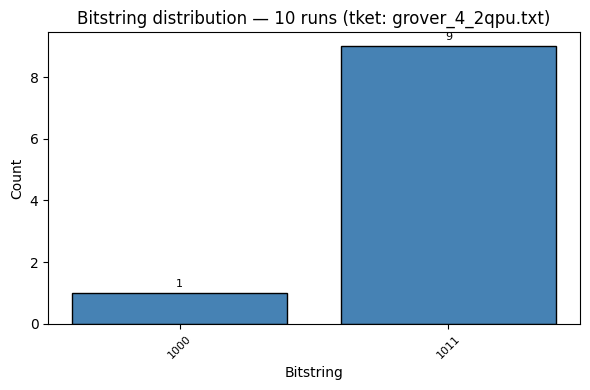

In [6]:
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt


if CIRCUIT_MODE == "cisco":
    CSV_PATH = (
        Path(_NB_DIR)
        / "results"
        / "grover4_3qpu_10iter_nopresched.csv"
    )
else:
    CSV_PATH = (
        Path(_NB_DIR)
        / "results"
        / "grover_4_2qpu_10iter_nopresched.csv"
    )

if not CSV_PATH.exists():
    raise FileNotFoundError(f"Results CSV not found: {CSV_PATH}")

# Read the header first so bitstrings can be preserved as strings.
columns = pd.read_csv(CSV_PATH, nrows=0).columns.str.strip().tolist()

dtype = {}
if "bitstring" in columns:
    # Important: preserves leading zeros such as "0011".
    dtype["bitstring"] = "string"

df = pd.read_csv(CSV_PATH, dtype=dtype)
df.columns = df.columns.str.strip()
# Detect per-qubit measurement columns.
meas_cols = [
    column
    for column in df.columns
    if column.startswith("m_") or column.startswith("QPU_")
]
print(f"{len(sim_results)} simulation run(s) completed")
print(f"Measurement columns: {meas_cols}")

bitstrings = df["bitstring"].tolist()
counts = Counter(bitstrings)
print(f"\nTop bitstrings:")
for bs, cnt in counts.most_common(10):
    pct = 100 * cnt / len(sim_results)
    print(f"  {bs}  ({cnt}/{len(sim_results)}, {pct:.1f}%)")

display_cols = ["run", "bitstring", "sim_duration_s"] + meas_cols
print(f"\nResults (first 10 rows):")
print(df[display_cols].head(10).to_string(index=False))

labels = sorted(counts.keys())
values = [counts[k] for k in labels]

fig, ax = plt.subplots(figsize=(max(6, len(labels) * 0.6), 4))
ax.bar(labels, values, color="steelblue", edgecolor="black")
ax.set_xlabel("Bitstring")
ax.set_ylabel("Count")
ax.set_title(f"Bitstring distribution — {NUM_RUNS} runs ({CIRCUIT_MODE}: {os.path.basename(CIRCUIT_FILE)})")
ax.tick_params(axis='x', rotation=45, labelsize=8)
for i, v in enumerate(values):
    ax.text(i, v + 0.2, str(v), ha="center", fontsize=8)
plt.tight_layout()
plt.show()